# Scene-depth experiment: ten bands per city

## tl;dr

This companion notebook tests whether the published city ranking survives a broader, balanced sample of ten bands per city. It does not replace the five-band publication notebook.

On the frozen Spotify snapshot from 17 July 2026, the untrimmed ten-band ranking starts with Sheffield, Manchester and Liverpool. Removing each city's largest band changes the top three to Manchester, Sheffield and London. Removing both the largest and smallest band produces Manchester, Sheffield and London.

The top-excluded and symmetric-trim variants produce the same city order. Manchester becomes first, Sheffield remains second after Arctic Monkeys is removed, and Liverpool falls from third to fifth after the Beatles are removed. The original order clearly depends on superstar concentration and catalogue breadth.


## 01. Context and methods

The published notebook uses `reference/original_shortlist.csv`: 50 bands, five per city. This experiment uses `reference/scene_depth_bands.csv`: 100 bands, ten per city.

Three population-normalized variants are compared:

1. **All ten:** sum all ten bands' monthly listeners and divide by built-up-area population.
2. **Highest excluded:** remove the largest band, sum the other nine and divide by population.
3. **Symmetric trim:** remove one highest and one lowest band, calculate the mean of the middle eight and divide by population.

Removing one observation from each tail is a 10% trim per tail, or 20% of observations removed overall. The primary symmetric-trim measure is the **population-normalized trimmed mean**: the middle-eight mean divided by built-up-area population. Because every city retains eight bands, its ranking is identical to the earlier trimmed-total formulation; only the displayed scale changes.

### Assumptions

- The manually curated 100-band catalogue is fixed. It cannot be recreated deterministically from scratch.
- Spotify monthly listeners measure global platform reach, not listening by local residents.
- Built-up-area population is a normalization denominator, not an estimate of each band's local audience.
- The 2021 population data and the selected Spotify snapshot refer to different dates.


In [1]:
# Locate the repository and import the reusable experiment code.
from pathlib import Path
import sys

import pandas as pd
from pandas.testing import assert_frame_equal
from IPython.display import display


def find_project_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "reference" / "scene_depth_bands.csv").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the uk-music-cities repository")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


def display_path(path: Path) -> Path:
    try:
        return path.relative_to(PROJECT_ROOT)
    except ValueError:
        return path


from python_uk_bands.analysis import build_city_rankings
from python_uk_bands.dataset import load_shortlist_dataset
from python_uk_bands.scene_depth import (
    build_scene_depth_rankings,
    validate_scene_depth_dataset,
)
from python_uk_bands.scene_depth_visuals import (
    plot_scene_depth_rank_comparison,
    plot_scene_depth_scores,
    plot_top_band_concentration,
)
from python_uk_bands.visuals import apply_chart_style

apply_chart_style()


## 02. Data

Notebook execution is offline and reads only frozen local inputs:

- `reference/scene_depth_bands.csv`: the fixed 100-band catalogue and row-level origin evidence.
- `data/processed/scene_depth_band_metrics_20260717T225650Z.csv`: band identities, monthly listeners and population.
- `data/processed/scene_depth_rankings_20260717T225650Z.csv`: the saved result used for the reproducibility check.
- `reference/original_shortlist.csv` and `data/processed/shortlist_spotify_metrics.json`: the published 50-band baseline used only for rank comparison.

The selected snapshot is **`20260717T225650Z`**, with Spotify metrics dated **17 July 2026**. No Spotify or MusicBrainz requests occur during notebook execution.


In [2]:
# Load the frozen experiment inputs.
SNAPSHOT_ID = "20260717T225650Z"
CATALOG_PATH = PROJECT_ROOT / "reference" / "scene_depth_bands.csv"
METRICS_PATH = PROJECT_ROOT / 'data/processed/scene_depth_band_metrics_20260717T225650Z.csv'
SAVED_RANKINGS_PATH = PROJECT_ROOT / 'data/processed/scene_depth_rankings_20260717T225650Z.csv'
CHART_OUTPUT_DIR = PROJECT_ROOT / 'artifacts/scene_depth/20260717T225650Z'

catalog = pd.read_csv(CATALOG_PATH, keep_default_na=False)
band_data = pd.read_csv(METRICS_PATH)
saved_rankings = pd.read_csv(SAVED_RANKINGS_PATH)

display(
    band_data[
        [
            "band",
            "city",
            "monthly_listeners",
            "population",
            "origin_confidence",
            "stats_extracted_at",
        ]
    ].head()
)


,band,city,monthly_listeners,population,origin_confidence,stats_extracted_at
0,The Rolling Stones,London,30644916,9540576,high,2026-07-17
1,The Clash,London,14556602,9540576,high,2026-07-17
2,Blur,London,14051908,9540576,high,2026-07-17
3,Coldplay,London,91959876,9540576,high,2026-07-17
4,Florence and the Machine,London,25889479,9540576,high,2026-07-17


### Data-quality checks

The design requires exactly 100 unique bands, ten cities and ten bands per city. Every row must have a positive population, a non-negative monthly-listener value and an exact reviewed Spotify name match.

The catalogue contains 6 medium-confidence origin assignments, all of which remain flagged for editorial review. That does not prevent calculation, but it limits how definitively the result should be presented.


In [3]:
# Validate the balanced design, identity coverage and frozen snapshot.
validate_scene_depth_dataset(
    band_data,
    expected_cities=10,
    bands_per_city=10,
)
assert len(band_data) == 100
assert band_data["band"].nunique() == 100
assert band_data["spotify_id"].nunique() == 100
assert band_data["match_quality"].eq("exact").all()
assert band_data["monthly_listeners"].ge(0).all()
assert band_data["stats_extracted_at"].nunique() == 1
assert set(catalog["band_name"]) == set(band_data["band"])

quality_summary = pd.DataFrame(
    {
        "Check": [
            "Bands",
            "Cities",
            "Bands per city",
            "Exact Spotify matches",
            "Medium-confidence origins",
            "Editorial-review flags",
        ],
        "Value": [
            len(band_data),
            band_data["city"].nunique(),
            int(band_data.groupby("city").size().min()),
            int(band_data["match_quality"].eq("exact").sum()),
            int(band_data["origin_confidence"].eq("medium").sum()),
            int(band_data["editorial_review_flag"].sum()),
        ],
    }
)
display(quality_summary)


,Check,Value
0,Bands,100
1,Cities,10
2,Bands per city,10
3,Exact Spotify matches,100
4,Medium-confidence origins,6
5,Editorial-review flags,6


## 03. Results

### 03.01 Recalculate and verify the saved result

The ranking is recomputed from the frozen band-level metrics. The cell then compares every saved output column with the timestamped result. Any discrepancy stops execution.


In [4]:
# Recalculate all three ranking variants and verify the saved snapshot.
rankings = build_scene_depth_rankings(
    band_data,
    metric="monthly_listeners",
    trim_each_tail=1,
    expected_cities=10,
    bands_per_city=10,
)
assert_frame_equal(
    rankings.loc[:, saved_rankings.columns],
    saved_rankings,
    check_exact=False,
    rtol=1e-12,
    atol=1e-12,
)

rank_table = rankings[
    [
        "city",
        "untrimmed_rank",
        "top_excluded_rank",
        "rank",
        "population_normalized_trimmed_mean",
        "highest_excluded_bands",
        "lowest_excluded_bands",
    ]
].rename(
    columns={
        "city": "City",
        "untrimmed_rank": "All ten rank",
        "top_excluded_rank": "Highest excluded rank",
        "rank": "High + low excluded rank",
        "population_normalized_trimmed_mean": (
            "Population-normalized trimmed mean"
        ),
        "highest_excluded_bands": "Highest excluded",
        "lowest_excluded_bands": "Lowest excluded",
    }
)
display(rank_table)


,City,All ten rank,Highest excluded rank,High + low excluded rank,Population-normalized trimmed mean,Highest excluded,Lowest excluded
0,Manchester,2,1,1,3.596684,Oasis,Happy Mondays
1,Sheffield,1,2,2,3.138313,Arctic Monkeys,Cabaret Voltaire
2,London,4,3,3,2.845889,Coldplay,The Kinks
3,Birmingham,5,4,4,2.845533,ELO,Ocean Colour Scene
4,Liverpool,3,5,5,2.072477,The Beatles,The Lightning Seeds
5,Glasgow,7,6,6,1.801444,Franz Ferdinand,Mogwai
6,Bristol,6,7,7,1.526600,Massive Attack,Roni Size / Reprazent
7,Leeds,8,8,8,1.105715,Alt-J,The Mission
8,Nottingham,9,9,9,0.589364,London Grammar,Six by Seven
9,Bradford,10,10,10,0.014786,New Model Army,The Passmore Sisters


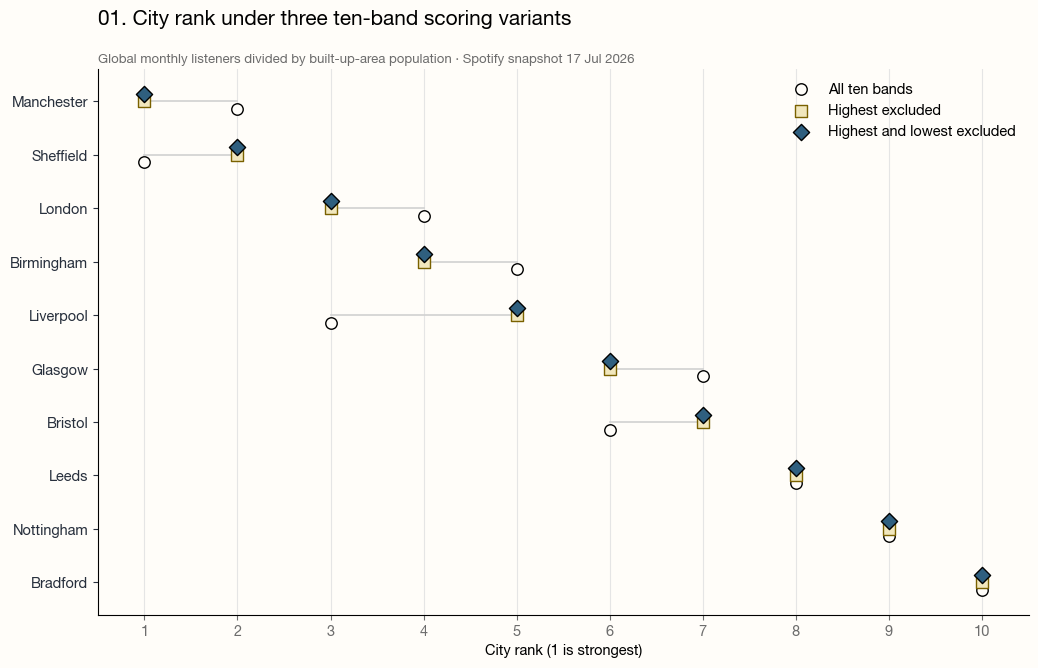

PosixPath('artifacts/scene_depth/20260717T225650Z/chart_01_scene_depth_rank_comparison.png')

In [5]:
# Compare city rank under the untrimmed and two trimmed variants.
figure_01_path = plot_scene_depth_rank_comparison(
    rankings,
    snapshot_date="17 Jul 2026",
    output_dir=CHART_OUTPUT_DIR,
)
display_path(figure_01_path)


The highest-only and symmetric-trim variants have identical ranks for all ten cities. Removing the smallest band therefore does not change the ordering in this snapshot; the rank changes come from removing the largest band.

Under the symmetric trim, Manchester, Sheffield and London are the top three cities.


### 03.02 Population-normalized trimmed mean

The population-normalized trimmed mean averages the middle eight bands' monthly listeners and divides that mean by built-up-area population. It is a comparative normalization ratio, not a local listening rate.


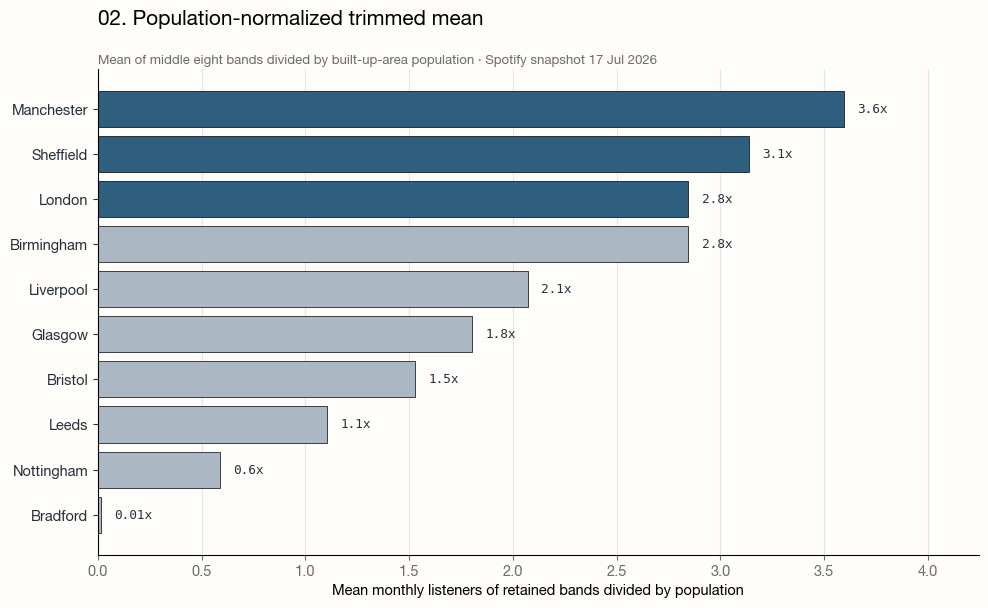

PosixPath('artifacts/scene_depth/20260717T225650Z/chart_02_scene_depth_scores.png')

In [6]:
# Plot the population-normalized mean of the middle eight bands.
figure_02_path = plot_scene_depth_scores(
    rankings,
    snapshot_date="17 Jul 2026",
    output_dir=CHART_OUTPUT_DIR,
)
display_path(figure_02_path)


London and Birmingham are effectively tied: their population-normalized trimmed means differ by only 0.01%. Their third- and fourth-place order should not be treated as a meaningful separation.


### 03.03 Superstar concentration

The chart shows how much of each untrimmed ten-band total comes from its largest band. A large share leaves the city more exposed to one act's current popularity.


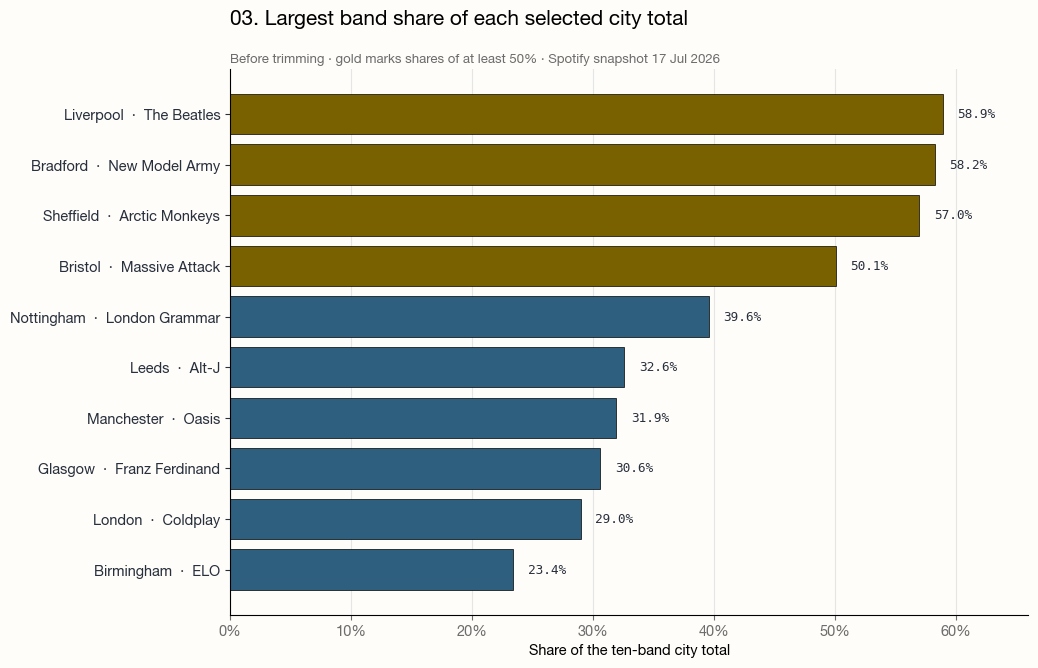

PosixPath('artifacts/scene_depth/20260717T225650Z/chart_03_top_band_concentration.png')

In [7]:
# Show how much of each city total comes from its largest selected band.
figure_03_path = plot_top_band_concentration(
    rankings,
    snapshot_date="17 Jul 2026",
    output_dir=CHART_OUTPUT_DIR,
)
display_path(figure_03_path)


The Beatles account for 58.9% of Liverpool's selected total, while Arctic Monkeys account for 57.0% of Sheffield's. Liverpool drops from third to fifth when its largest band is excluded. Sheffield slips from first to second, but its other selected bands still put the city near the top.


### 03.04 Comparison with the published five-band baseline

The published notebook uses five bands per city, a 100,000-follower eligibility threshold, the top three eligible bands and a September 2025 Spotify snapshot. This experiment uses ten bands, no follower threshold and a July 2026 snapshot. The comparison is a sensitivity check, not an apples-to-apples causal decomposition.


In [8]:
# Compare the experiment with the frozen published ranking.
FOLLOWER_THRESHOLD = 100_000
PUBLISHED_TOP_N = 3

published_bands = load_shortlist_dataset()
published_eligible = published_bands.loc[
    published_bands["followers"] >= FOLLOWER_THRESHOLD
].copy()
published_rankings = build_city_rankings(
    published_eligible,
    metric="monthly_listeners",
    top_n=PUBLISHED_TOP_N,
)

baseline_comparison = (
    published_rankings[["city", "rank"]]
    .rename(columns={"rank": "published_five_band_rank"})
    .merge(
        rankings[
            [
                "city",
                "untrimmed_rank",
                "top_excluded_rank",
                "rank",
            ]
        ].rename(columns={"rank": "symmetric_trim_rank"}),
        on="city",
        validate="one_to_one",
    )
    .sort_values("symmetric_trim_rank")
)
display(
    baseline_comparison.rename(
        columns={
            "city": "City",
            "published_five_band_rank": "Published rank",
            "untrimmed_rank": "Expanded all-ten rank",
            "top_excluded_rank": "Expanded top-excluded rank",
            "symmetric_trim_rank": "Expanded symmetric-trim rank",
        }
    )
)


,City,Published rank,Expanded all-ten rank,Expanded top-excluded rank,Expanded symmetric-trim rank
2,Manchester,3,2,1,1
0,Sheffield,1,1,2,2
5,London,6,4,3,3
4,Birmingham,5,5,4,4
1,Liverpool,2,3,5,5
6,Glasgow,7,7,6,6
3,Bristol,4,6,7,7
7,Leeds,8,8,8,8
8,Nottingham,9,9,9,9
9,Bradford,10,10,10,10


## 04. Takeaways

- The published top three are Sheffield, Liverpool and Manchester; the expanded symmetric-trim top three are Manchester, Sheffield and London.
- Manchester has the strongest result after the largest act is removed.
- Sheffield remains second after Arctic Monkeys is removed, so its result is not solely a single-band anomaly.
- Liverpool is more sensitive to the Beatles and falls two places after the largest act is removed.
- Removing the lowest act has no additional rank effect in this snapshot.

### 04.01 Limitations

The frozen files make this experiment reproducible, but the manually curated selection is still subjective. Six origin assignments are medium confidence and flagged for review. Spotify monthly listeners change over time, so a new snapshot may change both values and ranks. This only shows how robust this catalogue is; it cannot establish a definitive ranking of British music scenes.
